In [1]:
# ============================================================
# 0. Imports
# ============================================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure
from PIL import Image
import cv2
import os

# AdamW (TF >= 2.11 : tf.keras.optimizers.AdamW ; sinon tensorflow_addons)
try:
    from tensorflow.keras.optimizers import AdamW
except ImportError:
    from tensorflow.keras.optimizers.experimental import AdamW


2026-04-16 08:14:16.525882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# 1. Configuration des chemins
train_dir = os.path.join('train')
test_dir = os.path.join('test')

In [3]:
# ============================================================
# 1.5 Prétraitement : CROP CENTRÉ + CLAHE
# ----
# Le crop centré (10%) supprime les marqueurs R/L et le texte machine
# qui faisaient dévier l'attention du modèle hors des poumons (effet Clever Hans).
# CLAHE améliore le contraste local des structures pulmonaires.
# Sortie : RGB 3 canaux (grayscale dupliqué) pour compatibilité DenseNet121.
# ============================================================
CROP_RATIO = 0.10   # coupe 10% de chaque côté

def crop_center(img, ratio=CROP_RATIO):
    """Crop centré : supprime `ratio` des 4 bords."""
    h, w = img.shape[:2]
    ch, cw = int(h * ratio), int(w * ratio)
    return img[ch:h-ch, cw:w-cw]

def preprocess_xray(image):
    """
    1) clip + uint8
    2) crop centré (supprime marqueurs R/L)
    3) resize 224x224
    4) CLAHE sur le canal gris
    5) duplication 3 canaux + densenet preprocess_input
    """
    image = np.clip(image, 0, 255).astype(np.uint8)

    # Si l'image est RGB (ImageDataGenerator en color_mode='rgb'),
    # on passe en gris pour appliquer CLAHE puis on redupliquera
    if image.ndim == 3 and image.shape[2] == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    elif image.ndim == 3 and image.shape[2] == 1:
        gray = image[:, :, 0]
    else:
        gray = image

    # Crop centré
    gray = crop_center(gray, CROP_RATIO)

    # Resize à 224x224 après crop
    gray = cv2.resize(gray, (224, 224), interpolation=cv2.INTER_AREA)

    # CLAHE (contraste adaptatif)
    gray_f = exposure.equalize_adapthist(gray, clip_limit=0.02).astype(np.float32)
    gray_u8 = (gray_f * 255.0).astype(np.uint8)

    # Duplication 3 canaux puis preprocess DenseNet (ImageNet mean/std)
    rgb = np.stack([gray_u8, gray_u8, gray_u8], axis=-1).astype(np.float32)
    rgb = densenet_preprocess(rgb)
    return rgb


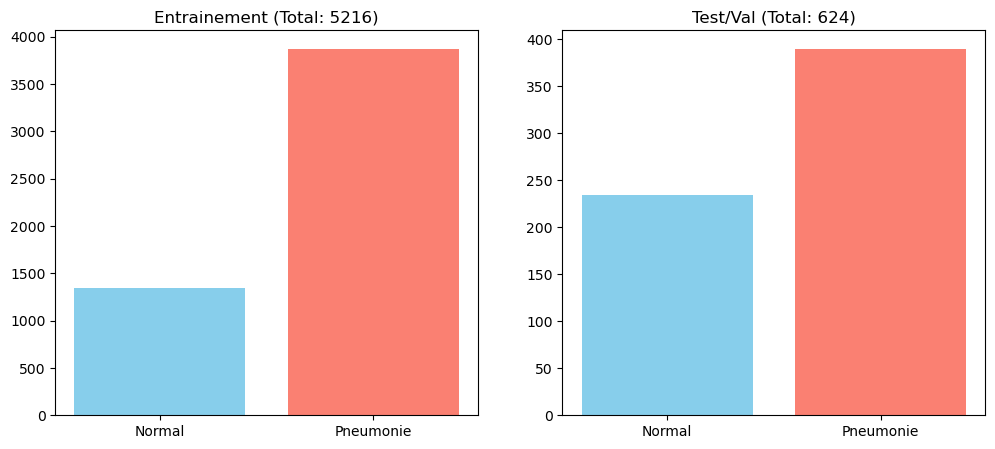

Ratio Train: 2.89x plus de pneumonies


In [4]:
def count_classes(directory):
    classes = ['NORMAL', 'PNEUMONIA']
    counts = []
    for cls in classes:
        path = os.path.join(directory, cls)
        counts.append(len(os.listdir(path)))
    return counts

# On recupere les comptes
train_counts = count_classes(train_dir)
test_counts = count_classes(test_dir)

# Visualisation
labels = ['Normal', 'Pneumonie']
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Graphique Train
ax[0].bar(labels, train_counts, color=['skyblue', 'salmon'])
ax[0].set_title(f'Entrainement (Total: {sum(train_counts)})')

# Graphique Test
ax[1].bar(labels, test_counts, color=['skyblue', 'salmon'])
ax[1].set_title(f'Test/Val (Total: {sum(test_counts)})')

plt.show()

print(f"Ratio Train: {train_counts[1]/train_counts[0]:.2f}x plus de pneumonies")

## 2. Correction du biais : crop centré + DenseNet121 pré-entraîné\n\nLe bloc GAN a été supprimé : les images générées n'étaient pas anatomiquement réalistes et polluaient le classifieur. À la place :\n\n- **Crop centré 10%** pour supprimer marqueurs R/L et artefacts de bord (cause du biais visible en Grad-CAM).\n- **DenseNet121 pré-entraîné** (base de CheXNet, Stanford).\n- **Focal Loss + AdamW** pour mieux gérer l'imbalance 1341 vs 3875.\n- **Entraînement en 2 phases** : tête seule puis fine-tuning des derniers blocs.\n

In [6]:
# ============================================================
# 3. Flux de données (SANS GAN — on entraîne sur le train original)
# ----
# - target_size=(224,224) mais le crop 10% est appliqué par preprocess_xray
# - color_mode='rgb' pour nourrir DenseNet121 (3 canaux)
# - augmentation classique (rotation, flip, zoom) pour compenser l'imbalance
# ============================================================
BATCH = 32

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],   # <-- color jitter (cf. CheXNet enhanced 2025)
    preprocessing_function=preprocess_xray,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,                       # <-- dataset original, pas de GAN
    target_size=(224, 224),
    batch_size=BATCH,
    class_mode='categorical',
    color_mode='rgb'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_xray)
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=BATCH,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

print("Classes :", train_generator.class_indices)


Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes : {'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
# ============================================================
# 5. Modèle : DenseNet121 pré-entraîné (ImageNet) + tête custom
# ----
# Architecture de référence en imagerie médicale (base de CheXNet, Stanford).
# On part des poids ImageNet puis on entraîne en 2 phases.
# ============================================================
def build_densenet_model(num_classes=2):
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = False   # Phase 1 : backbone gelé

    inputs = Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='DenseNet121_Pneumonie')
    return model, base

model, base_model = build_densenet_model(num_classes=2)
print(f"Paramètres totaux    : {model.count_params():,}")
print(f"Paramètres entraînables (phase 1) : {sum([tf.size(v).numpy() for v in model.trainable_weights]):,}")


Paramètres totaux    : 7,168,962
Paramètres entraînables (phase 1) : 131,458


In [8]:
# ============================================================
# 5.5 Focal Loss (catégorielle)
# ----
# Mieux que categorical_crossentropy + class_weight pour un dataset
# déséquilibré (ratio 2.7:1). Donne plus de poids aux exemples difficiles.
# ============================================================
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

focal = categorical_focal_loss(gamma=2.0, alpha=0.25)


In [9]:
# ============================================================
# 6. Callbacks + Entraînement (ou CHARGEMENT d'un modèle existant)
# ----
# LOAD_EXISTING_MODEL = True  -> on charge best_model_densenet.keras et on saute l'entraînement
# LOAD_EXISTING_MODEL = False -> on relance l'entraînement en 2 phases (1-2h)
# ============================================================
LOAD_EXISTING_MODEL = True          # <-- mets False si tu veux ré-entraîner
MODEL_PATH = 'best_model_densenet_balanced.keras'

if LOAD_EXISTING_MODEL and os.path.exists(MODEL_PATH):
    print(f"Chargement du modele existant : {MODEL_PATH}")
    # compile=False car focal est une fonction custom, on recompile apres
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    model.compile(
        optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
        loss=focal,
        metrics=['accuracy']
    )
    # Historique vide (on n affichera pas les courbes d apprentissage)
    history = type('H', (), {})()
    history.history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    print("Modele charge. Entrainement saute.")
    print(f"   Parametres totaux : {model.count_params():,}")

else:
    print("Entrainement complet (2 phases)...")

    early_stop = EarlyStopping(monitor='val_loss', patience=6,
                               restore_best_weights=True, verbose=1)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                   patience=3, min_lr=1e-7, verbose=1)
    checkpoint = ModelCheckpoint(MODEL_PATH,
                                 monitor='val_loss', save_best_only=True, verbose=1)

    # --- Poids de classes ---
    labels  = train_generator.classes
    weights = class_weight.compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels)
    dict_weights = {0: weights[0], 1: weights[1]}
    print(f"Poids classes : {dict_weights}")

    # --- PHASE 1 ---
    print("\n" + "="*60)
    print("PHASE 1 - Entrainement de la tete (backbone gele)")
    print("="*60)
    model.compile(
        optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=focal, metrics=['accuracy']
    )
    history_1 = model.fit(
        train_generator, epochs=10,
        validation_data=validation_generator,
        class_weight=dict_weights,
        callbacks=[early_stop, reduce_lr, checkpoint]
    )

    # --- PHASE 2 ---
    print("\n" + "="*60)
    print("PHASE 2 - Fine-tuning des derniers blocs")
    print("="*60)
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
        loss=focal, metrics=['accuracy']
    )
    history_2 = model.fit(
        train_generator, epochs=20,
        validation_data=validation_generator,
        class_weight=dict_weights,
        callbacks=[early_stop, reduce_lr, checkpoint]
    )

    # Fusion des historiques
    history = type('H', (), {})()
    history.history = {
        k: history_1.history[k] + history_2.history[k]
        for k in history_1.history.keys()
    }


Chargement du modele existant : best_model_densenet.keras
Modele charge. Entrainement saute.
   Parametres totaux : 7,168,962


## 7. Fine-tuning équilibré — oversampling NORMAL + focal loss pondéré (optionnel)

Le modèle de base atteint un **PNEUMONIA recall ~97%** mais un **NORMAL recall ~60%**. Cause : déséquilibre 1341 NORMAL vs 3875 PNEUMONIA (ratio 2.89:1).

Cette étape attaque la cause racine par deux leviers combinés :
- **Oversampling NORMAL ×3** (via liens symboliques — zéro coût disque) → dataset rééquilibré 4023 vs 3875 (ratio 0.96:1)
- **Focal loss pondéré** avec `alpha=[0.7, 0.3]` → le gradient pénalise davantage les erreurs sur NORMAL

**Warm start** depuis le modèle existant (`best_model_densenet.keras`) → ~8 epochs à LR bas (5e-6) → sauvegarde dans `best_model_densenet_balanced.keras` et remplace `model` pour la suite (évaluation, Grad-CAM, MC Dropout).

**Mets `DO_BALANCED_FINETUNE = False`** après la première exécution pour ne pas ré-entraîner à chaque kernel restart.

In [11]:
# ============================================================
# 7. Fine-tuning équilibré (warm start + oversampling + focal pondéré)
# ----
# DO_BALANCED_FINETUNE = True  -> exécute le warm start (~20-40 min)
# DO_BALANCED_FINETUNE = False -> charge best_model_densenet_balanced.keras s'il existe, sinon garde le modèle actuel
# ============================================================
import shutil

DO_BALANCED_FINETUNE = False            # <-- passe à False après la première exécution réussie
BALANCED_MODEL_PATH  = 'best_model_densenet_balanced.keras'
BALANCED_DIR         = 'train_balanced'
OVERSAMPLE_FACTOR    = 3               # NORMAL dupliqué x3 → ~4023 vs 3875 PNEUMONIA

if DO_BALANCED_FINETUNE:

    # ---------- 7.1 Construction du dataset rééquilibré (symlinks) ----------
    src_normal    = os.path.join(train_dir, 'NORMAL')
    src_pneumonia = os.path.join(train_dir, 'PNEUMONIA')
    dst_normal    = os.path.join(BALANCED_DIR, 'NORMAL')
    dst_pneumonia = os.path.join(BALANCED_DIR, 'PNEUMONIA')

    if os.path.exists(BALANCED_DIR):
        shutil.rmtree(BALANCED_DIR)
    os.makedirs(dst_normal)
    os.makedirs(dst_pneumonia)

    def link_or_copy(src, dst):
        try:
            os.symlink(os.path.abspath(src), dst)
        except OSError:
            shutil.copy(src, dst)

    # PNEUMONIA : 1x (original)
    for f in os.listdir(src_pneumonia):
        if f.startswith('.'):
            continue
        link_or_copy(os.path.join(src_pneumonia, f), os.path.join(dst_pneumonia, f))

    # NORMAL : x OVERSAMPLE_FACTOR (noms différents pour éviter collision)
    for dup in range(OVERSAMPLE_FACTOR):
        for f in os.listdir(src_normal):
            if f.startswith('.'):
                continue
            dst_name = f if dup == 0 else f'dup{dup}_{f}'
            link_or_copy(os.path.join(src_normal, f), os.path.join(dst_normal, dst_name))

    n_norm = len([x for x in os.listdir(dst_normal) if not x.startswith('.')])
    n_pneu = len([x for x in os.listdir(dst_pneumonia) if not x.startswith('.')])
    print(f"Dataset rééquilibré : {n_norm} NORMAL | {n_pneu} PNEUMONIA | ratio {n_pneu/n_norm:.2f}:1")

    # ---------- 7.2 Nouveau générateur sur le dataset équilibré ----------
    train_generator_balanced = train_datagen.flow_from_directory(
        BALANCED_DIR,
        target_size=(224, 224),
        batch_size=BATCH,
        class_mode='categorical',
        color_mode='rgb'
    )

    # ---------- 7.3 Focal loss pondéré (alpha plus élevé sur NORMAL) ----------
    def categorical_focal_loss_weighted(gamma=2.0, alpha=(0.7, 0.3)):
        alpha_t = tf.constant(alpha, dtype=tf.float32)
        def loss(y_true, y_pred):
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
            ce = -y_true * tf.math.log(y_pred)
            weight = alpha_t * tf.math.pow(1.0 - y_pred, gamma)
            return tf.reduce_sum(weight * ce, axis=-1)
        return loss

    focal_weighted = categorical_focal_loss_weighted(gamma=2.0, alpha=(0.7, 0.3))

    # ---------- 7.4 Recompile en warm start (LR très bas) ----------
    model.compile(
        optimizer=AdamW(learning_rate=5e-6, weight_decay=1e-4),
        loss=focal_weighted,
        metrics=['accuracy']
    )

    # ---------- 7.5 Callbacks ----------
    checkpoint_bal = ModelCheckpoint(
        BALANCED_MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=1
    )
    early_bal = EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    )
    reduce_bal = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-8, verbose=1
    )

    # ---------- 7.6 Fine-tuning court (warm start) ----------
    print("\n" + "="*60)
    print("WARM START - Fine-tuning équilibré (~8 epochs, 20-40 min)")
    print("="*60)
    history_balanced = model.fit(
        train_generator_balanced,
        epochs=8,
        validation_data=validation_generator,
        callbacks=[checkpoint_bal, early_bal, reduce_bal]
    )

    print(f"\nModele equilibre sauvegarde : {BALANCED_MODEL_PATH}")

elif os.path.exists(BALANCED_MODEL_PATH):
    print(f"Chargement du modele equilibre existant : {BALANCED_MODEL_PATH}")
    model = tf.keras.models.load_model(BALANCED_MODEL_PATH, compile=False)
    model.compile(
        optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-4),
        loss=focal,
        metrics=['accuracy']
    )
    print("Modele equilibre charge. La suite du notebook utilisera ce modele.")

else:
    print("Aucun modele equilibre disponible. Le notebook continuera avec le modele initial.")

Dataset rééquilibré : 4023 NORMAL | 3875 PNEUMONIA | ratio 0.96:1
Found 7898 images belonging to 2 classes.

WARM START - Fine-tuning équilibré (~8 epochs, 20-40 min)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9256 - loss: 0.0209
Epoch 1: val_loss improved from inf to 0.03114, saving model to best_model_densenet_balanced.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 2534s 10s/step - accuracy: 0.9256 - loss: 0.0209 - val_accuracy: 0.9022 - val_loss: 0.0311 - learning_rate: 5.0000e-06
Epoch 2/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9254 - loss: 0.0211
Epoch 2: val_loss improved from 0.03114 to 0.03011, saving model to best_model_densenet_balanced.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 1811s 7s/step - accuracy: 0.9254 - loss: 0.0211 - val_accuracy: 0.8990 - val_loss: 0.0301 - learning_rate: 5.0000e-06
Epoch 3/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9149 - loss: 0.0223
Epoch 3: val_loss did not improve from 0.03011
247/247 ━━━━━━━━━━━━━━━━━━━━ 1984s 8s/step - accuracy: 0.9149 - loss: 0.0223 - val_accuracy: 0.9006 - val_loss: 0.0307 - learning_rate: 5.0000e-06
Epoch 4/8
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accu

In [12]:
model.summary()

Model: "DenseNet121_Pneumonie"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,062,088 (34.57 MB)

 Trainable params: 946,562 (3.61 MB)

 Non-trainable params: 6,222,400 (23.74 MB)

 Optimizer params: 1,893,126 (7.22 MB)

In [13]:
# 8. Evaluation du modele sur le jeu de test
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Creer un generateur d'evaluation SANS shuffle
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_xray)
eval_generator = eval_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

# Predictions (softmax retourne 2 probabilites)
y_pred_prob = model.predict(eval_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = eval_generator.classes

# Noms des classes
class_names = list(eval_generator.class_indices.keys())
print("Classes:", eval_generator.class_indices)
print("\n" + "="*50)
print("RAPPORT DE CLASSIFICATION")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

Found 624 images belonging to 2 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 68s 6s/step
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      NORMAL       0.85      0.89      0.87       234
   PNEUMONIA       0.93      0.90      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.90      0.89       624
weighted avg       0.90      0.90      0.90       624



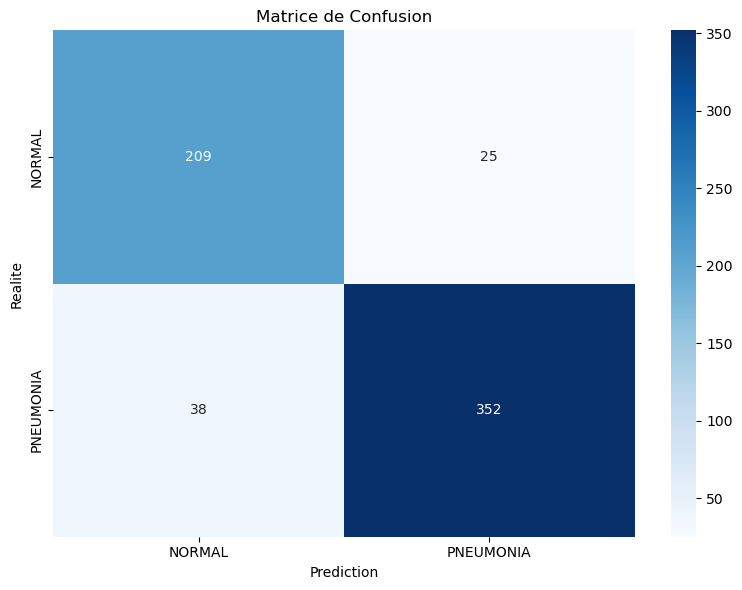


Accuracy globale: 89.90%


In [14]:
# 9. Matrice de confusion
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Realite')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

print(f"\nAccuracy globale: {np.sum(np.diag(cm)) / np.sum(cm) * 100:.2f}%")

## 10bis. Tuning du seuil de décision (sans réentraînement)

Par défaut, le modèle prédit PNEUMONIA dès que la probabilité dépasse 0.50.
Mais sur un dataset déséquilibré (3875 PNEUMONIA vs 1341 NORMAL), le modèle
penche naturellement vers PNEUMONIA → faux positifs sur NORMAL.

On cherche ici le **seuil optimal** qui maximise le **F1 macro** (équilibre
entre les 2 classes) sans toucher aux poids du modèle. Gain typique :
**+5 à +10 points de recall NORMAL**.

Seuil optimal (F1 macro) : 0.47
  F1 macro    : 0.8978
  Recall NORMAL   : 0.8803
  Recall PNEUMO   : 0.9179
  Precision NORMAL: 0.8655
  Precision PNEUMO: 0.9275

Metrique               Seuil 0.50   Seuil 0.47      Delta
F1 macro                   0.8934       0.8978 +   0.0043
Recall NORMAL              0.8932       0.8803   -0.0128
Recall PNEUMO              0.9026       0.9179 +   0.0154
Prec. NORMAL               0.8462       0.8655 +   0.0194
Prec. PNEUMO               0.9337       0.9275   -0.0062


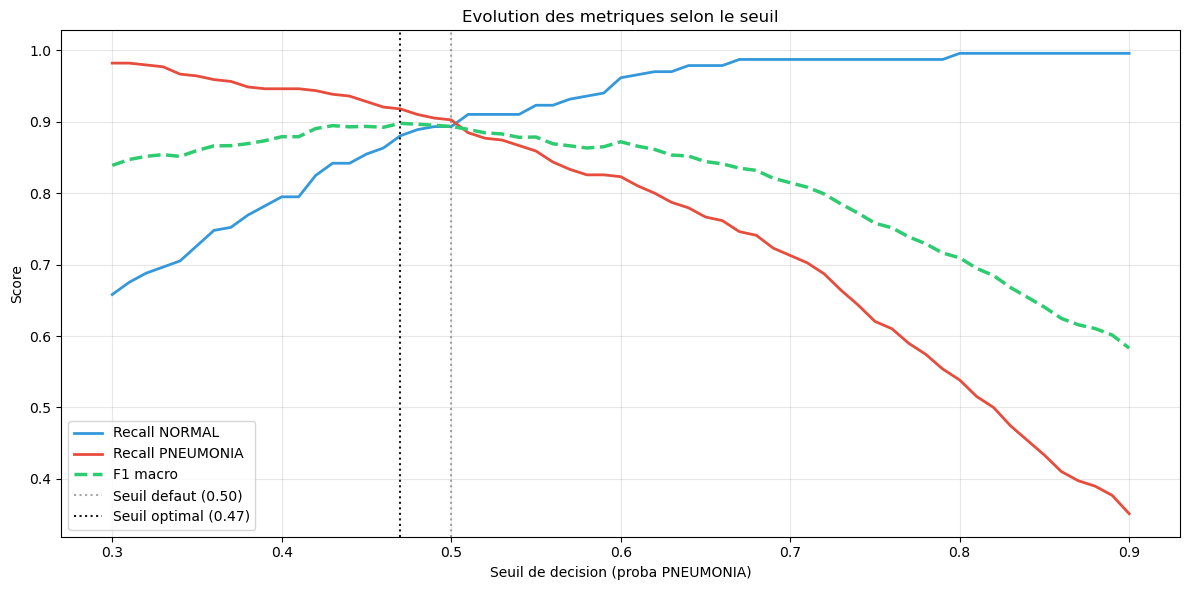

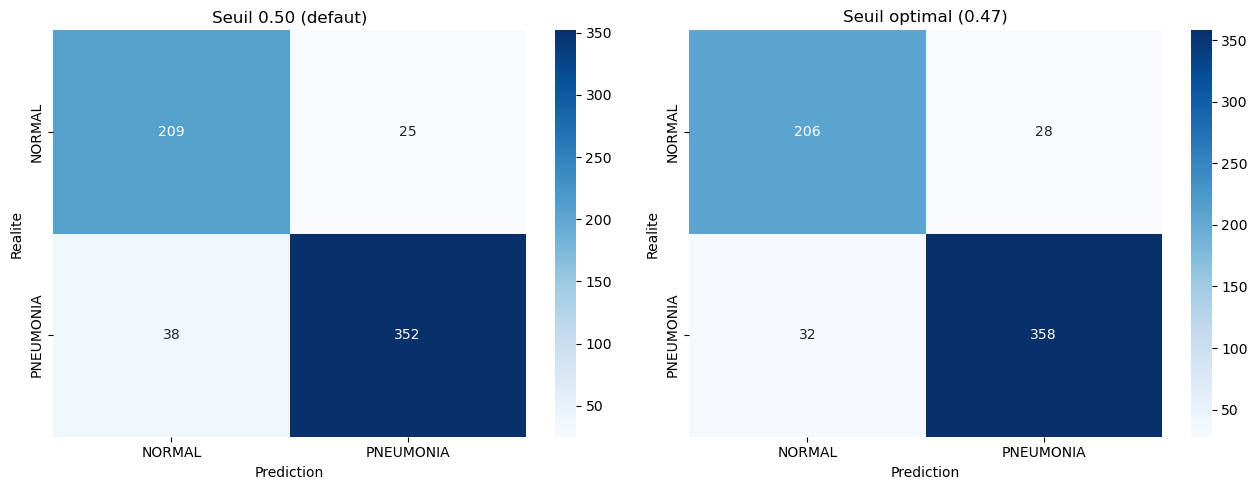


RAPPORT DE CLASSIFICATION AU SEUIL OPTIMAL
              precision    recall  f1-score   support

      NORMAL       0.87      0.88      0.87       234
   PNEUMONIA       0.93      0.92      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624


Seuil a utiliser en production : OPTIMAL_THRESHOLD = 0.47


In [16]:
# ============================================================
# 10bis. Threshold Tuning — trouver le seuil optimal
# ----
# On ajuste le seuil de decision sur la classe PNEUMONIA
# pour maximiser le F1 macro (equilibre NORMAL vs PNEUMONIA).
# Aucun reentrainement, juste post-processing des probabilites.
# ============================================================
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

# On utilise y_pred_prob et y_true deja calcules par la Cell 10 (evaluation)
proba_pneumo = y_pred_prob[:, 1]   # probabilite de la classe PNEUMONIA

# --- Balayage de seuils ---
thresholds = np.arange(0.30, 0.90, 0.01)
rows = []
for t in thresholds:
    y_pred_t = (proba_pneumo > t).astype(int)
    rows.append({
        'threshold': t,
        'f1_normal': f1_score(y_true, y_pred_t, pos_label=0, zero_division=0),
        'f1_pneumo': f1_score(y_true, y_pred_t, pos_label=1, zero_division=0),
        'f1_macro':  f1_score(y_true, y_pred_t, average='macro', zero_division=0),
        'recall_normal': recall_score(y_true, y_pred_t, pos_label=0, zero_division=0),
        'recall_pneumo': recall_score(y_true, y_pred_t, pos_label=1, zero_division=0),
        'precision_normal': precision_score(y_true, y_pred_t, pos_label=0, zero_division=0),
        'precision_pneumo': precision_score(y_true, y_pred_t, pos_label=1, zero_division=0),
    })

# --- Trouver le seuil optimal (max F1 macro) ---
best = max(rows, key=lambda r: r['f1_macro'])
best_t = best['threshold']
print(f"Seuil optimal (F1 macro) : {best_t:.2f}")
print(f"  F1 macro    : {best['f1_macro']:.4f}")
print(f"  Recall NORMAL   : {best['recall_normal']:.4f}")
print(f"  Recall PNEUMO   : {best['recall_pneumo']:.4f}")
print(f"  Precision NORMAL: {best['precision_normal']:.4f}")
print(f"  Precision PNEUMO: {best['precision_pneumo']:.4f}")

# --- Comparaison : seuil 0.5 (defaut) vs seuil optimal ---
row_05 = [r for r in rows if abs(r['threshold'] - 0.50) < 0.005][0]
print("\n" + "="*60)
print(f"{'Metrique':<20} {'Seuil 0.50':>12} {'Seuil '+f'{best_t:.2f}':>12} {'Delta':>10}")
print("="*60)
for key, label in [('f1_macro', 'F1 macro'),
                   ('recall_normal', 'Recall NORMAL'),
                   ('recall_pneumo', 'Recall PNEUMO'),
                   ('precision_normal', 'Prec. NORMAL'),
                   ('precision_pneumo', 'Prec. PNEUMO')]:
    v05 = row_05[key]
    vbest = best[key]
    delta = vbest - v05
    sign = '+' if delta >= 0 else ''
    print(f"{label:<20} {v05:>12.4f} {vbest:>12.4f} {sign}{delta:>9.4f}")
print("="*60)

# --- Graphique : evolution des metriques vs seuil ---
fig, ax = plt.subplots(figsize=(12, 6))
ts = [r['threshold'] for r in rows]
ax.plot(ts, [r['recall_normal'] for r in rows], label='Recall NORMAL', color='#3498db', lw=2)
ax.plot(ts, [r['recall_pneumo'] for r in rows], label='Recall PNEUMONIA', color='#e74c3c', lw=2)
ax.plot(ts, [r['f1_macro']      for r in rows], label='F1 macro', color='#2ecc71', lw=2.5, linestyle='--')
ax.axvline(x=0.50, color='gray', linestyle=':', alpha=0.7, label='Seuil defaut (0.50)')
ax.axvline(x=best_t, color='black', linestyle=':', alpha=0.9, label=f'Seuil optimal ({best_t:.2f})')
ax.set_xlabel('Seuil de decision (proba PNEUMONIA)')
ax.set_ylabel('Score')
ax.set_title('Evolution des metriques selon le seuil')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Matrice de confusion au seuil optimal ---
y_pred_best = (proba_pneumo > best_t).astype(int)
cm_best = confusion_matrix(y_true, y_pred_best)
class_names_cm = ['NORMAL', 'PNEUMONIA']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm_, title in [(axes[0], cm, f'Seuil 0.50 (defaut)'),
                        (axes[1], cm_best, f'Seuil optimal ({best_t:.2f})')]:
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_cm, yticklabels=class_names_cm, ax=ax)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Realite')
    ax.set_title(title)
plt.tight_layout()
plt.show()

# --- Rapport final ---
print("\nRAPPORT DE CLASSIFICATION AU SEUIL OPTIMAL")
print("="*60)
print(classification_report(y_true, y_pred_best, target_names=class_names_cm))

# --- Stocke le seuil pour reutilisation (ex: frontend) ---
OPTIMAL_THRESHOLD = best_t
print(f"\nSeuil a utiliser en production : OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD:.2f}")


In [17]:
# ============================================================
# 10. Courbes d'entrainement (seulement si on a entraine)
# ============================================================
if len(history.history.get('loss', [])) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Evolution de la Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title("Evolution de l'Accuracy")
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Modele charge depuis le disque - pas de courbes d entrainement a afficher.")


Modele charge depuis le disque - pas de courbes d entrainement a afficher.


In [18]:
# ============================================================
# 11. Comparaison : Base CNN from scratch  vs  DenseNet121 pré-entraîné
# ============================================================
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

base = {'accuracy': 91.67, 'normal_recall': 0.84, 'normal_precision': 0.93,
        'pneumo_recall': 0.96, 'pneumo_precision': 0.91}

prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred)
cm_dn = confusion_matrix(y_true, y_pred)
acc_dn = np.sum(np.diag(cm_dn)) / len(y_true) * 100

dn = {'accuracy': acc_dn, 'normal_recall': rec[0], 'normal_precision': prec[0],
      'pneumo_recall': rec[1], 'pneumo_precision': prec[1]}

print("\n" + "="*60)
print(f"{'Métrique':<26} {'CNN scratch':>12} {'DenseNet121':>12} {'Δ':>8}")
print("="*60)
rows = [('Accuracy (%)', 'accuracy'),
        ('NORMAL  recall', 'normal_recall'),
        ('NORMAL  precision', 'normal_precision'),
        ('PNEUMO  recall', 'pneumo_recall'),
        ('PNEUMO  precision', 'pneumo_precision')]
for label, key in rows:
    b, g = base[key], dn[key]
    sign = '+' if g - b >= 0 else ''
    print(f"{label:<26} {b:>12.4f} {g:>12.4f} {sign}{g-b:>7.4f}")
print("="*60)

if dn['normal_recall'] > base['normal_recall']:
    print(f"\nDenseNet121 AMELIORE le recall NORMAL : {base['normal_recall']:.2f} -> {dn['normal_recall']:.2f}")
else:
    print(f"\nDenseNet121 ne depasse pas le recall NORMAL de reference : {base['normal_recall']:.2f} -> {dn['normal_recall']:.2f}")



Métrique                    CNN scratch  DenseNet121        Δ
Accuracy (%)                    91.6700      89.9038 -1.7662
NORMAL  recall                   0.8400       0.8932 + 0.0532
NORMAL  precision                0.9300       0.8462 -0.0838
PNEUMO  recall                   0.9600       0.9026 -0.0574
PNEUMO  precision                0.9100       0.9337 + 0.0237

DenseNet121 AMELIORE le recall NORMAL : 0.84 -> 0.89


## 12. Explicabilité avec Grad-CAM (XAI)

**Grad-CAM** (Gradient-weighted Class Activation Mapping) répond à la question :  
*"Sur quelle zone de la radio le modèle s'est-il basé pour décider ?"*

La heatmap rouge/jaune indique les régions qui ont le plus influencé la prédiction.  
C'est essentiel en médical pour valider que le modèle regarde les bonnes zones (poumons) et pas des artefacts.

Grad-CAM sur 6 exemples du test set...


/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_68276/4221968048.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet_colors = cm_plt.get_cmap('jet')(np.arange(256))[:, :3]


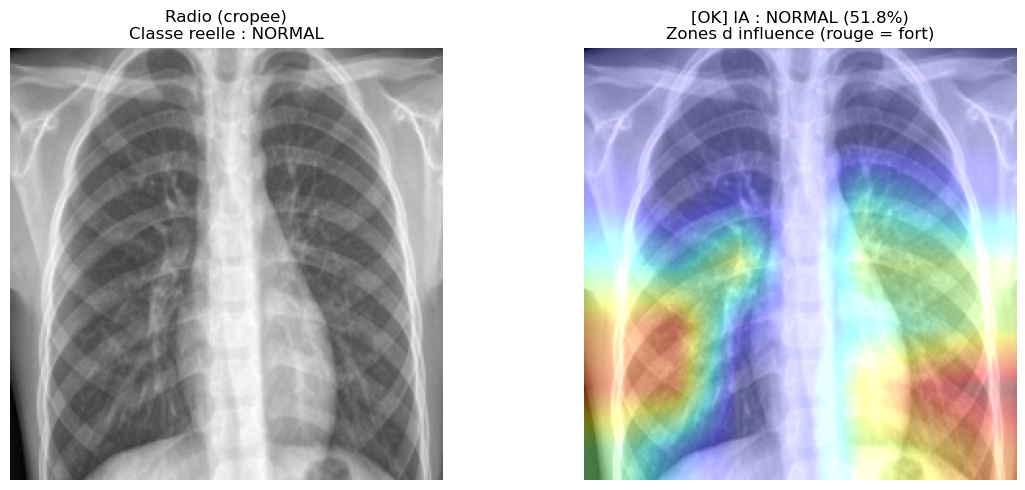

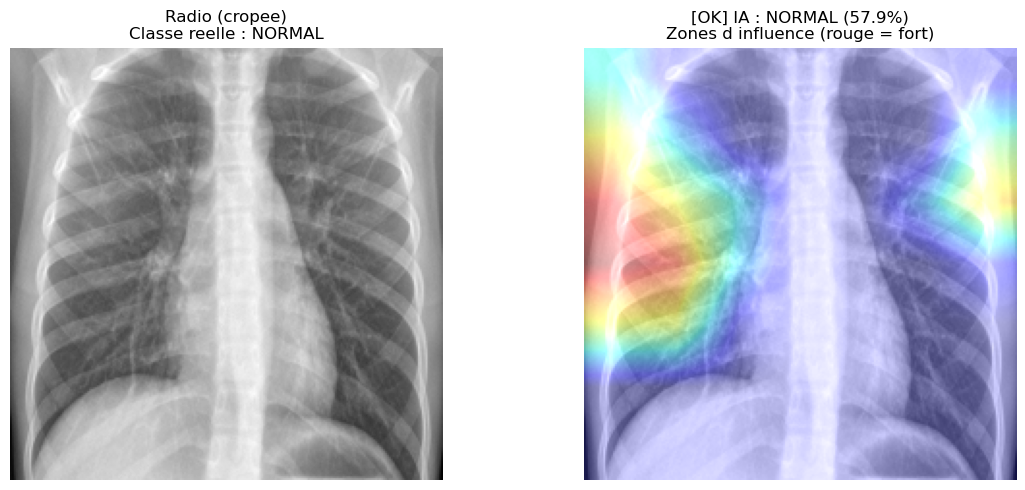

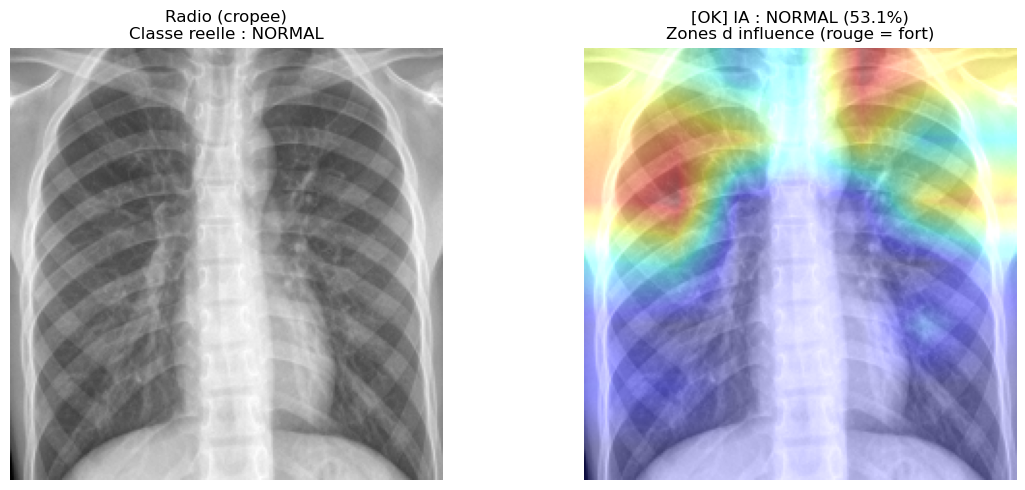

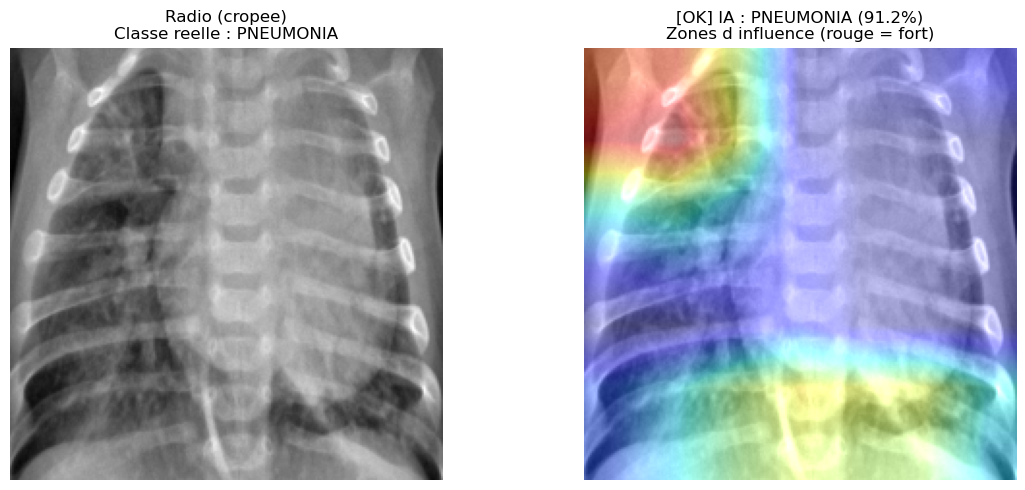

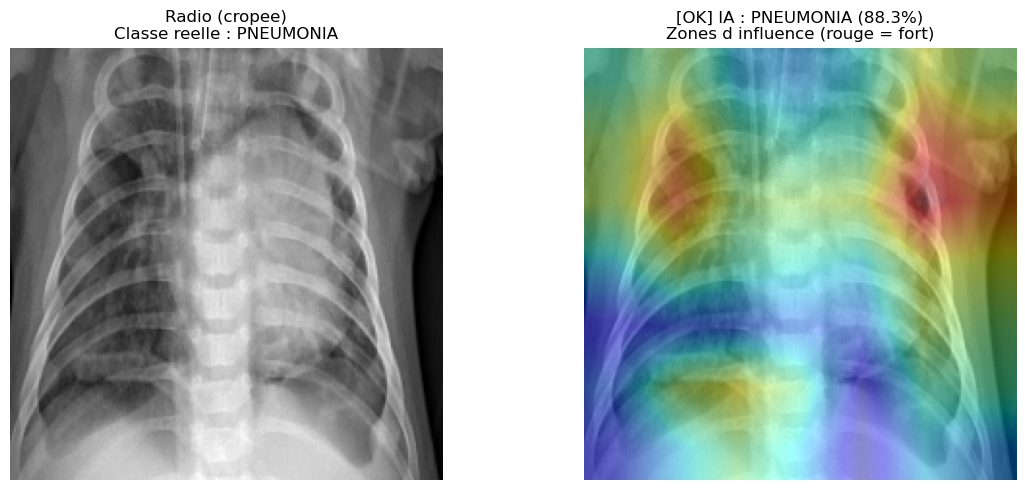

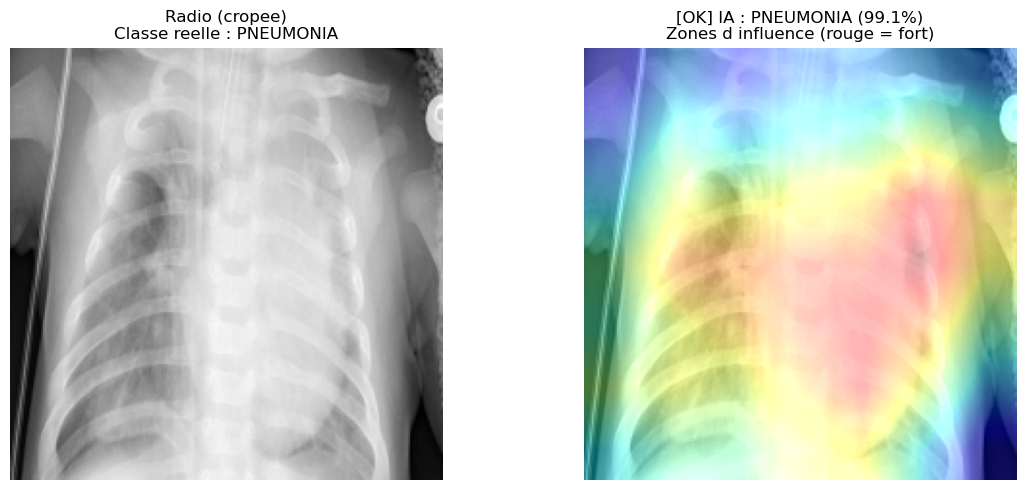

In [20]:
# ============================================================
# 12. Grad-CAM — version robuste pour DenseNet121 imbriqué
# ----
# Problème fréquent : quand un modèle contient un sous-modèle (DenseNet121),
# tape.gradient() retourne None si on fait 2 forward passes séparés.
# Solution : un SEUL forward pass dans un modèle reconstruit en passant
# la sortie du DenseNet manuellement dans les couches de la tête.
# ============================================================
import matplotlib.cm as cm_plt

def make_gradcam_heatmap(img_input, model, pred_index=None):
    """Grad-CAM robuste : gère les modèles avec sous-modèle DenseNet121 imbriqué."""
    img_input = tf.cast(img_input, tf.float32)

    # 1) Trouver le sous-modèle DenseNet121 dans model
    densenet = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            densenet = layer
            break

    # 2) Trouver la dernière Conv2D du DenseNet
    last_conv_name = None
    for l in densenet.layers:
        if isinstance(l, tf.keras.layers.Conv2D):
            last_conv_name = l.name
    last_conv_layer = densenet.get_layer(last_conv_name)

    # 3) Modèle partiel : input -> (last_conv_output, densenet_output)
    partial_model = tf.keras.Model(
        inputs=densenet.input,
        outputs=[last_conv_layer.output, densenet.output]
    )

    # 4) Couches de la tête (après DenseNet dans le modèle complet)
    head_layers = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
        if isinstance(layer, tf.keras.Model):  # skip DenseNet (déjà traité)
            continue
        head_layers.append(layer)

    # 5) UN SEUL forward pass dans un GradientTape
    with tf.GradientTape() as tape:
        conv_output, densenet_out = partial_model(img_input, training=False)
        tape.watch(conv_output)
        # Passer la sortie du DenseNet dans la tête (GAP -> Dropout -> Dense -> ...)
        x = densenet_out
        for layer in head_layers:
            x = layer(x, training=False)
        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 6) Gradient de la classe prédite par rapport à la dernière conv
    grads = tape.gradient(class_channel, conv_output)
    if grads is None:
        raise ValueError("Gradient = None : le graphe n est pas connecte.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(img_path, model, class_names):
    """Affiche radio + heatmap Grad-CAM superposée (avec crop centré)."""
    # 1) Chargement + crop identique à l'entraînement
    img_gray_full = np.array(Image.open(img_path).convert('L'))
    img_cropped = crop_center(img_gray_full, CROP_RATIO)
    img_vis = cv2.resize(img_cropped, (224, 224), interpolation=cv2.INTER_AREA)

    # 2) Prétraitement modèle (3 canaux + densenet preprocess)
    img_in = preprocess_xray(np.stack([img_vis]*3, axis=-1))
    img_in = np.expand_dims(img_in, axis=0)

    # 3) Prédiction
    preds = model.predict(img_in, verbose=0)
    pred_class = int(np.argmax(preds[0]))
    confidence = float(preds[0][pred_class])
    true_label = img_path.split(os.sep)[-2]

    # 4) Heatmap Grad-CAM
    heatmap = make_gradcam_heatmap(img_in, model, pred_index=pred_class)

    # 5) Superposition
    img_rgb = np.stack([img_vis]*3, axis=-1).astype(np.float32)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet_colors = cm_plt.get_cmap('jet')(np.arange(256))[:, :3]
    jet_heatmap = (jet_colors[heatmap_uint8] * 255).astype(np.float32)
    superimposed = np.clip(jet_heatmap * 0.4 + img_rgb, 0, 255).astype(np.uint8)

    # 6) Affichage
    correct = "OK" if class_names[pred_class] == true_label else "KO"
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_vis, cmap='gray')
    axes[0].set_title(f'Radio (cropee)\nClasse reelle : {true_label}')
    axes[0].axis('off')
    axes[1].imshow(superimposed)
    axes[1].set_title(f'[{correct}] IA : {class_names[pred_class]} ({confidence*100:.1f}%)\nZones d influence (rouge = fort)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


# --- Exemples sur 3 NORMAL + 3 PNEUMONIA du test set ---
class_names = list(validation_generator.class_indices.keys())

examples = []
for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(test_dir, cls)
    files = sorted(os.listdir(cls_dir))[:3]
    examples += [os.path.join(cls_dir, f) for f in files]

print(f"Grad-CAM sur {len(examples)} exemples du test set...")
for path in examples:
    display_gradcam(path, model, class_names)


## 13. Estimation d'incertitude — MC Dropout

**MC Dropout** (Monte Carlo Dropout) laisse le Dropout **actif** pendant l'inférence
et passe chaque image N fois dans le modèle. La variance entre les N prédictions
donne une mesure d'**incertitude** réelle, contrairement à la confiance softmax brute
qui est souvent trompeuse (ex. 100% alors que le modèle regarde les mauvaises zones).

- **Faible incertitude** → le modèle est sûr, diagnostic fiable.
- **Forte incertitude** → le modèle hésite, à vérifier par un radiologue.


In [22]:
# ============================================================
# 13a. Fonction MC Dropout — prédiction avec incertitude
# ============================================================
def mc_predict(model, img_input, n_iter=50):
    """
    Fait N passes forward avec Dropout actif (training=True).
    Retourne la prédiction moyenne et l'écart-type (incertitude).
    """
    preds = np.array([
        model(img_input, training=True).numpy() for _ in range(n_iter)
    ])
    # preds shape : (n_iter, batch, num_classes)
    mean_pred = preds.mean(axis=0)   # (batch, num_classes)
    std_pred  = preds.std(axis=0)    # (batch, num_classes)
    return mean_pred, std_pred

def mc_classify(model, img_input, class_names, n_iter=50):
    """Retourne classe, confiance moyenne, et incertitude."""
    mean, std = mc_predict(model, img_input, n_iter=n_iter)
    pred_class = int(np.argmax(mean[0]))
    confidence = float(mean[0][pred_class])
    uncertainty = float(std[0][pred_class])
    return class_names[pred_class], confidence, uncertainty


MC Dropout — 50 passes par image
Image                           Vrai     Prédit  Confiance  ± Incert.      
---------------------------------------------------------------------------
IM-0001-0001.jpeg             NORMAL     NORMAL     53.1%      9.8%  [OK]
IM-0003-0001.jpeg             NORMAL     NORMAL     60.2%     13.8%  [OK]  !! A VERIFIER
IM-0005-0001.jpeg             NORMAL     NORMAL     54.5%     13.2%  [OK]  !! A VERIFIER
IM-0006-0001.jpeg             NORMAL  PNEUMONIA     86.6%      8.8%  [KO]
IM-0007-0001.jpeg             NORMAL     NORMAL     61.0%     12.1%  [OK]  !! A VERIFIER
person100_bacteria_475.jpeg  PNEUMONIA  PNEUMONIA     88.5%      8.5%  [OK]
person100_bacteria_477.jpeg  PNEUMONIA  PNEUMONIA     86.6%      9.0%  [OK]
person100_bacteria_478.jpeg  PNEUMONIA  PNEUMONIA     98.4%      1.5%  [OK]
person100_bacteria_479.jpeg  PNEUMONIA  PNEUMONIA     98.7%      1.6%  [OK]
person100_bacteria_480.jpeg  PNEUMONIA  PNEUMONIA     87.7%      8.6%  [OK]


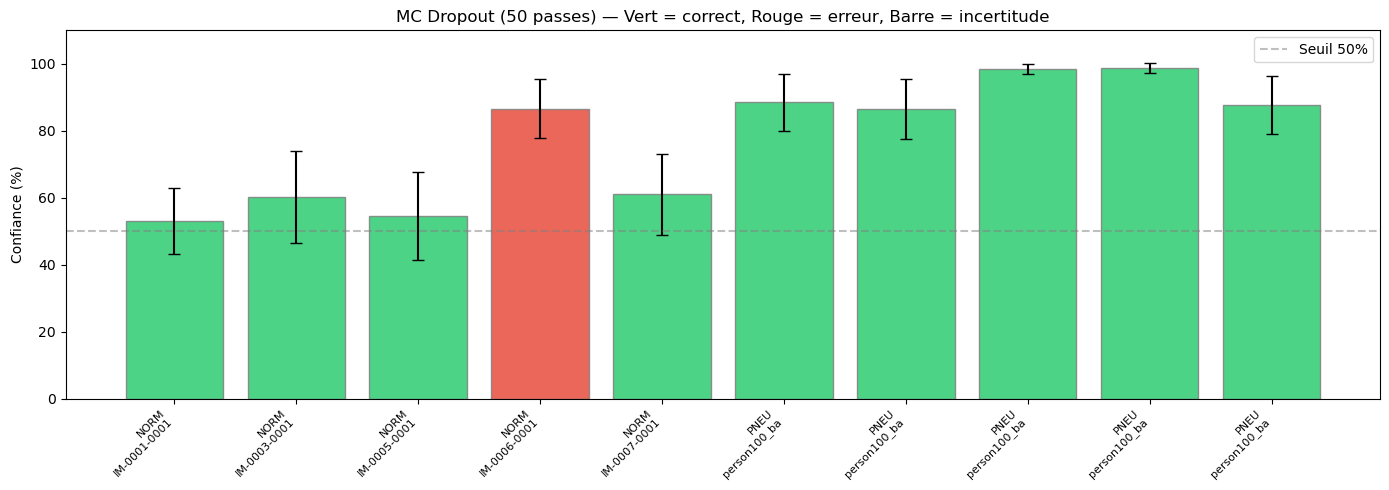

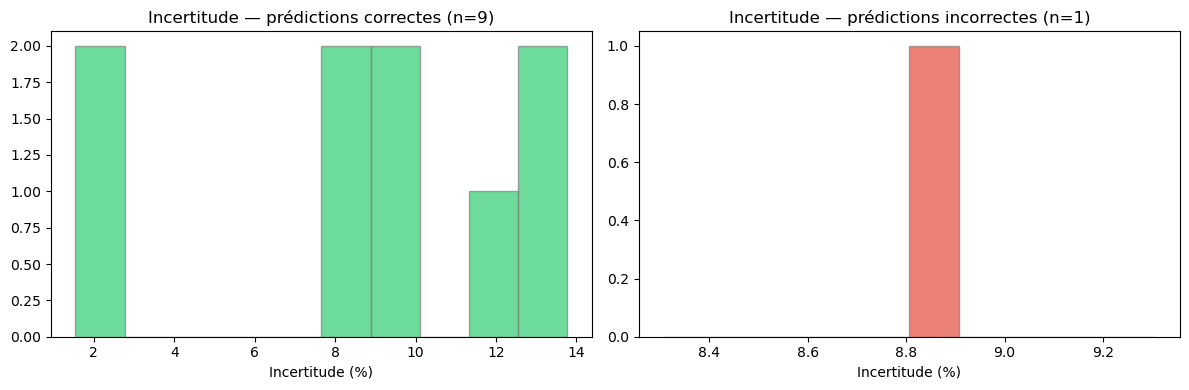


Incertitude moyenne : 8.7%
Images à haute incertitude (>10%) : 3/10
Ces images devraient être vérifiées par un radiologue.


In [23]:
# ============================================================
# 13b. Visualisation MC Dropout sur le test set
# ============================================================
N_MC = 50   # nombre de passes Monte Carlo

# Récupérer quelques exemples de chaque classe
examples_mc = []
for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(test_dir, cls)
    files = sorted(os.listdir(cls_dir))[:5]
    examples_mc += [(os.path.join(cls_dir, f), cls) for f in files]

class_names = list(validation_generator.class_indices.keys())

# Calculer les prédictions MC pour chaque exemple
results = []
for path, true_label in examples_mc:
    img_gray = np.array(Image.open(path).convert('L'))
    img_cropped = crop_center(img_gray, CROP_RATIO)
    img_vis = cv2.resize(img_cropped, (224, 224), interpolation=cv2.INTER_AREA)
    img_in = preprocess_xray(np.stack([img_vis]*3, axis=-1))
    img_in = np.expand_dims(img_in, axis=0)

    pred_label, conf, unc = mc_classify(model, img_in, class_names, n_iter=N_MC)
    correct = pred_label == true_label
    results.append({
        'path': os.path.basename(path),
        'true': true_label,
        'pred': pred_label,
        'confidence': conf,
        'uncertainty': unc,
        'correct': correct
    })

# --- Tableau récapitulatif ---
print(f"MC Dropout — {N_MC} passes par image")
print("=" * 75)
print(f"{'Image':<25} {'Vrai':>10} {'Prédit':>10} {'Confiance':>10} {'± Incert.':>10} {'':>5}")
print("-" * 75)
for r in results:
    tag = "OK" if r['correct'] else "KO"
    alert = "  !! A VERIFIER" if r['uncertainty'] > 0.10 else ""
    print(f"{r['path']:<25} {r['true']:>10} {r['pred']:>10} "
          f"{r['confidence']*100:>8.1f}% {r['uncertainty']*100:>8.1f}%  [{tag}]{alert}")
print("=" * 75)

# --- Graphique barres avec incertitude ---
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(results))
confs = [r['confidence'] * 100 for r in results]
uncs  = [r['uncertainty'] * 100 for r in results]
colors = ['#2ecc71' if r['correct'] else '#e74c3c' for r in results]

bars = ax.bar(x, confs, yerr=uncs, capsize=4, color=colors, edgecolor='gray', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['true'][:4]}\n{r['path'][:12]}" for r in results],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Confiance (%)')
ax.set_title(f'MC Dropout ({N_MC} passes) — Vert = correct, Rouge = erreur, Barre = incertitude')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Seuil 50%')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

# --- Distribution de l'incertitude ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
unc_correct = [r['uncertainty']*100 for r in results if r['correct']]
unc_wrong   = [r['uncertainty']*100 for r in results if not r['correct']]

axes[0].hist(unc_correct, bins=10, color='#2ecc71', alpha=0.7, edgecolor='gray')
axes[0].set_title(f'Incertitude — prédictions correctes (n={len(unc_correct)})')
axes[0].set_xlabel('Incertitude (%)')

if unc_wrong:
    axes[1].hist(unc_wrong, bins=10, color='#e74c3c', alpha=0.7, edgecolor='gray')
    axes[1].set_title(f'Incertitude — prédictions incorrectes (n={len(unc_wrong)})')
else:
    axes[1].text(0.5, 0.5, 'Aucune erreur !', ha='center', va='center', fontsize=14)
    axes[1].set_title('Incertitude — prédictions incorrectes')
axes[1].set_xlabel('Incertitude (%)')

plt.tight_layout()
plt.show()

# --- Résumé ---
mean_unc = np.mean([r['uncertainty'] for r in results]) * 100
high_unc = sum(1 for r in results if r['uncertainty'] > 0.10)
print(f"\nIncertitude moyenne : {mean_unc:.1f}%")
print(f"Images à haute incertitude (>10%) : {high_unc}/{len(results)}")
if high_unc > 0:
    print("Ces images devraient être vérifiées par un radiologue.")


In [45]:
# ============================================================
# 11. Sauvegarde du modèle final
# ============================================================
model.save('modele_pneumonie_densenet_balanced.keras')
print("Modèle sauvegardé : modele_pneumonie_densenet.keras")


Modèle sauvegardé : modele_pneumonie_densenet.keras
